In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o"
)

llm_response = llm.invoke("What is the capital of France?")
print(llm_response.content)

The capital of France is Paris.


In [9]:
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

@tool
def search(query: str) -> TavilySearchResults:
    """Search the web for a given query."""
    tavily = TavilySearchResults()
    result = tavily.invoke({"query": query})
    return f"Result for '{query}': \n {result}"

search_response = search.invoke("What is the capital of France?")
print(search_response)

Result for 'What is the capital of France?': 
 [{'title': 'What are the three official capitals of France and which one ... - Quora', 'url': 'https://www.quora.com/What-are-the-three-official-capitals-of-France-and-which-one-is-the-most-commonly-visited', 'content': "What is the capital of France? What are some of its major cities?\n\nThe capital of France is Paris. It is not only the country's capital but also its largest city and a global center for art, culture, fashion, and cuisine. Paris is home to iconic landmarks such as the Eiffel Tower, Louvre Museum, Notre-Dame Cathedral, and the Champs-Élysées. [...] The capital of France is Paris. It is not only the country's capital but also its largest city and a global center for art, culture, fashion, and cuisine. Paris is home to iconic landmarks such as the Eiffel Tower, Louvre Museum, Notre-Dame Cathedral, and the Champs-Élysées.\n\nApart from Paris, France has several other major cities that are significant in terms of population, e

In [7]:
@tool
def multiplier(x: int, y: int) -> int:
    """Multiply two numbers."""
    return x * y

multiplier_response = multiplier.invoke({"x": 3, "y": 4})
print(multiplier_response)

12


In [14]:
tools = [search, multiplier]
llm_with_tools = llm.bind_tools(tools)

In [15]:
result = llm_with_tools.invoke("Whats the gdp of india?")

In [16]:
result.tool_calls

[{'name': 'search',
  'args': {'query': 'GDP of India 2023'},
  'id': 'call_8m4dePNyb0FeCbH5xZU77aEx',
  'type': 'tool_call'}]

In [17]:
tool_mapping = {tool.name: tool for tool in tools}

In [18]:
tool_mapping

{'search': StructuredTool(name='search', description='Search the web for a given query.', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x1226430a0>),
 'multiplier': StructuredTool(name='multiplier', description='Multiply two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiplier'>, func=<function multiplier at 0x1223d6b00>)}

In [20]:
tool_mapping[result.tool_calls[0]["name"]].invoke(result.tool_calls[0]["args"])

'Result for \'GDP of India 2023\': \n [{\'title\': \'Press Release: Press Information Bureau\', \'url\': \'https://pib.gov.in/PressReleaseIframePage.aspx?PRID=2022323\', \'content\': \'style="margin-right:4.25pt; text-align:justify"><span style="font-family:Times New Roman,Times,serif"><span style="font-size:16px">&#160;&#160;&#160;&#160;&#160;&#160;&#160;&#160;&#160;&#160;&#160; Real GDP or GDP at Constant Prices is estimated to attain a level of ₹173.82 lakh crore in the year 2023-24, against the First Revised Estimates (FRE) of GDP for the year 2022-23 of ₹160.71 lakh crore. The growth rate in Real GDP during 2023-24 is estimated at 8.2% as compared to 7.0% in 2022-23. [...] Real GDP or GDP at Constant Prices is estimated to attain a level of ₹173.82 lakh crore in the year 2023-24, against the First Revised Estimates (FRE) of GDP for the year 2022-23 of ₹160.71 lakh crore. The growth rate in Real GDP during 2023-24 is estimated at 8.2% as compared to 7.0% in 2022-23. Nominal GDP or 

In [21]:
from typing import TypedDict, Sequence, Annotated
import operator
from langchain_core.messages import HumanMessage, BaseMessage

In [22]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [35]:
def invoke_model(state: AgentState):
    messages = state["messages"]
    question = messages[-1]
    response = llm_with_tools.invoke(question)
    return {"messages": [response]}

In [36]:
def router(state: AgentState):
    tool_calls = state["messages"][-1].tool_calls
    if tool_calls:
        return "tool"
    else:
        return "end"

In [43]:
def invoke_tool(state: AgentState):
    tool_details = state["messages"][-1].tool_calls
    if tool_details is None:
        return Exception("No tool calls found in the last message.")
    print(f"Selected tool: {tool_details[0]['name']}")
    
    if tool_details[0]["name"] == "search":
        response=input(prompt=f"[yes/no] Do you want to continue with this expensive web search?")
        if response.lower() == "no":
            print("web seach discarded by the user. Exiting gracefully.")
            raise Exception("Web search discarded by the user.")
            
    
    response = tool_mapping[tool_details[0]["name"]].invoke(tool_details[0]["args"])
    return {"messages": [response]}

In [44]:
from langgraph.graph import StateGraph, START, END

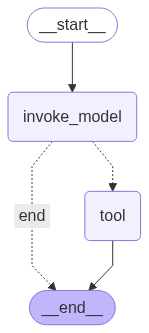

In [45]:
graph = StateGraph(AgentState)
graph.add_node("invoke_model", invoke_model)
graph.add_node("tool", invoke_tool)

graph.add_conditional_edges(
    "invoke_model",
    router,
    {
        "tool": "tool",
        "end": END
    }
)

graph.add_edge("tool", END)
graph.set_entry_point("invoke_model")

app = graph.compile()

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [40]:
app.invoke({"messages": ["What is the gdp of india?"]})

Selected tool: search


{'messages': ['What is the gdp of india?',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_0VKeREaI9XVHAPzn54nGmf13', 'function': {'arguments': '{"query":"GDP of India 2023"}', 'name': 'search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 73, 'total_tokens': 91, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-BpFNJw3nhkBWBKAIa0jduc7bnq4L7', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--3ffdc5c3-f8cb-45b4-8112-5a8088143ebd-0', tool_calls=[{'name': 'search', 'args': {'query': 'GDP of India 2023'}, 'id': 'call_0VKeREaI9XVHAPzn54nGmf13', 'type': 'tool_call'}], usage_metadata={'input_tokens': 73, 'output_tokens':

In [41]:
app.invoke({"messages": ["What is the multiplication of 5 and 20?"]})

Selected tool: multiplier


{'messages': ['What is the multiplication of 5 and 20?',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_yyHbKmNlqHbZ6qnE5UhO21fX', 'function': {'arguments': '{"x":5,"y":20}', 'name': 'multiplier'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 76, 'total_tokens': 94, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-BpFNpdJDZyHFZm1421VduIsffpmkK', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--3aa2aa16-1b0e-432e-a295-63bc5f04f082-0', tool_calls=[{'name': 'multiplier', 'args': {'x': 5, 'y': 20}, 'id': 'call_yyHbKmNlqHbZ6qnE5UhO21fX', 'type': 'tool_call'}], usage_metadata={'input_tokens': 76, 'output_tokens': 18, '

In [46]:
app.invoke({"messages": ["What is the gdp of india?"]})

Selected tool: search
web seach discarded by the user. Exiting gracefully.


Exception: Web search discarded by the user.